# Classificando a Qualidade de Vinhos com Machine Learning
### Tech Challenge — Fase 2 | POSTECH Data Analytics

Pipeline completa de análise e modelagem para prever, a partir de características
físico-químicas, se um vinho é de **Alta Qualidade (nota ≥ 7)** ou de
**Baixa/Média Qualidade (nota < 7)**.

**Sumário**
1. Compreensão do problema e definição da variável alvo
2. Análise Exploratória de Dados (EDA)
3. Pré-processamento e feature engineering
4. Desenvolvimento de modelos (3 algoritmos)
5. Avaliação e comparação
6. Interpretação dos resultados e implicações para a produção

## 1. Compreensão do Problema

A avaliação sensorial de vinhos é subjetiva e cara. O objetivo aqui é construir um modelo que use **11 medições físico-químicas** (objetivas, coletadas em laboratório) para prever a classe de qualidade, apoiando enólogos na padronização do produto.

**Transformação do alvo:** a nota original (3 a 8) é binarizada em `high_quality = 1` se nota ≥ 7, senão `0`.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
SPOT_RED = '#E3001B'

df = pd.read_csv('../data/WineQT.csv')
print('Shape original:', df.shape)
df.head()

Shape original: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [2]:
# Remover Id (identificador, sem valor preditivo)
df = df.drop(columns=['Id'])
# Binarizar o alvo
df['high_quality'] = (df['quality'] >= 7).astype(int)
print(df['quality'].value_counts().sort_index())
print('\nDistribuição binária:')
print(df['high_quality'].value_counts())
print(f"Alta qualidade: {df['high_quality'].mean()*100:.1f}%")

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Distribuição binária:
high_quality
0    984
1    159
Name: count, dtype: int64
Alta qualidade: 13.9%


## 2. Análise Exploratória de Dados

### 2.1 Qualidade dos dados: nulos e duplicatas

In [3]:
print('Valores nulos por coluna:')
print(df.isnull().sum().sum(), 'nulos no total')

FEATURES = ['fixed acidity','volatile acidity','citric acid','residual sugar',
    'chlorides','free sulfur dioxide','total sulfur dioxide','density','pH',
    'sulphates','alcohol']
dups = df.duplicated(subset=FEATURES).sum()
print(f'Linhas duplicadas (mesmas features): {dups}')
# Removemos duplicatas para evitar vazamento entre treino e teste
df = df.drop_duplicates(subset=FEATURES, keep='first').reset_index(drop=True)
print('Shape após remoção de duplicatas:', df.shape)

Valores nulos por coluna:
0 nulos no total
Linhas duplicadas (mesmas features): 125
Shape após remoção de duplicatas: (1018, 13)


### 2.2 Balanceamento das classes

O dataset é **fortemente desbalanceado**: apenas ~14% das amostras são de alta qualidade. Isso exige cuidado na modelagem (estratificação, ponderação de classes) e na escolha de métricas (acurácia sozinha seria enganosa).

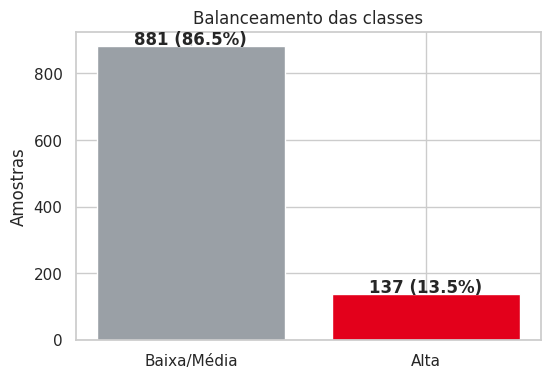

In [4]:
fig, ax = plt.subplots(figsize=(6,4))
c = df['high_quality'].value_counts().sort_index()
ax.bar(['Baixa/Média','Alta'], c.values, color=['#9aa0a6', SPOT_RED])
for i,v in enumerate(c.values): ax.text(i, v+5, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Balanceamento das classes'); ax.set_ylabel('Amostras'); plt.show()

### 2.3 Correlações

Investigamos como cada variável se relaciona com a qualidade. A matriz usa o coeficiente de Pearson.

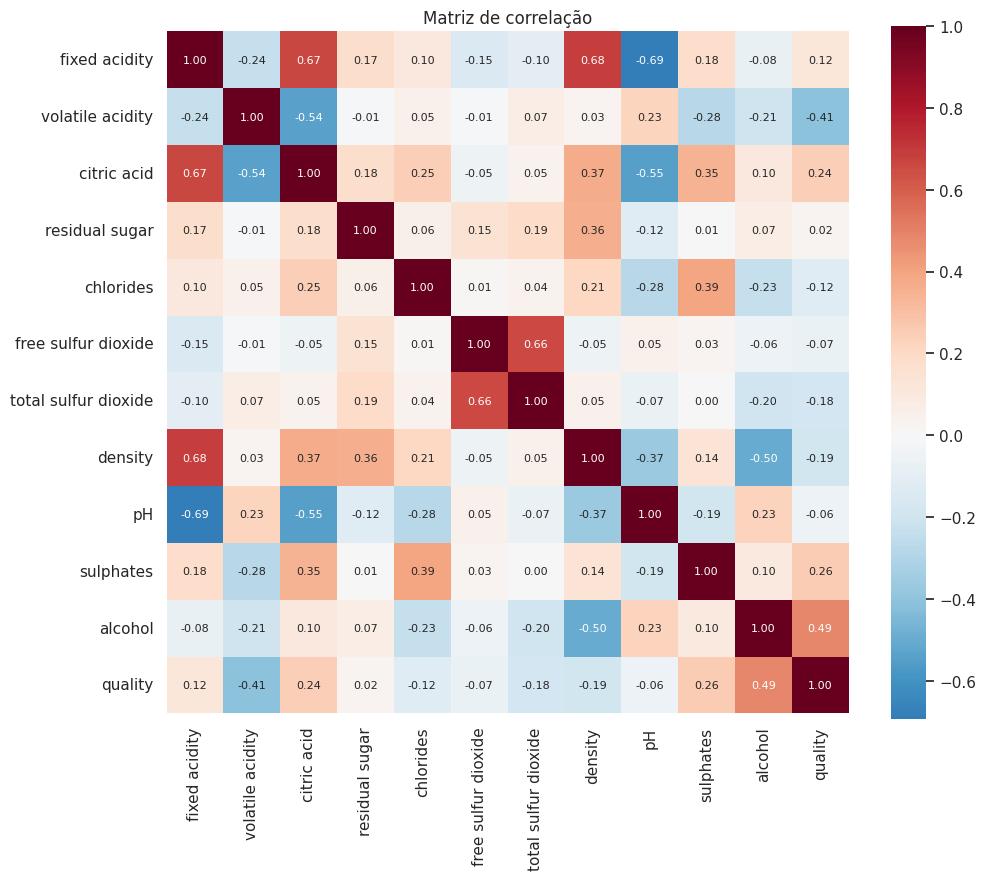

In [5]:
corr = df[FEATURES+['quality']].corr()
fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            annot_kws={'size':8}, ax=ax)
ax.set_title('Matriz de correlação'); plt.show()

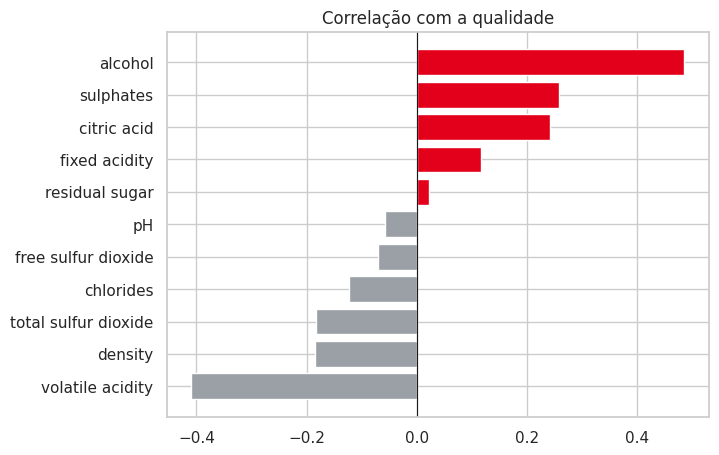

alcohol                 0.485953
sulphates               0.257519
citric acid             0.241565
fixed acidity           0.115826
residual sugar          0.022718
pH                     -0.057592
free sulfur dioxide    -0.071083
chlorides              -0.122214
total sulfur dioxide   -0.182214
density                -0.185187
volatile acidity       -0.409340
Name: quality, dtype: float64


In [6]:
# Correlação ordenada com a qualidade
cq = corr['quality'].drop('quality').sort_values()
fig, ax = plt.subplots(figsize=(7,5))
ax.barh(cq.index, cq.values, color=[SPOT_RED if v>0 else '#9aa0a6' for v in cq.values])
ax.axvline(0, color='k', lw=.8); ax.set_title('Correlação com a qualidade'); plt.show()
print(cq.sort_values(ascending=False))

**Leitura das correlações (justificativa de cada uma):**

- **Álcool (r ≈ +0,49):** correlação positiva mais forte. Vinhos mais encorpados e
  com maior teor alcoólico tendem a ser melhor avaliados.
- **Acidez volátil (r ≈ −0,41):** correlação negativa mais forte. Alta acidez volátil
  está ligada ao defeito de "avinagrado" (ácido acético) — derruba a nota.
- **Sulfatos (r ≈ +0,26) e ácido cítrico (r ≈ +0,24):** positivos. Sulfatos atuam como
  conservante/antioxidante; ácido cítrico agrega frescor.
- **Densidade (r ≈ −0,19):** negativa, e fortemente ligada ao álcool (vinhos mais
  alcoólicos são menos densos).

### 2.4 Distribuição das variáveis-chave por classe

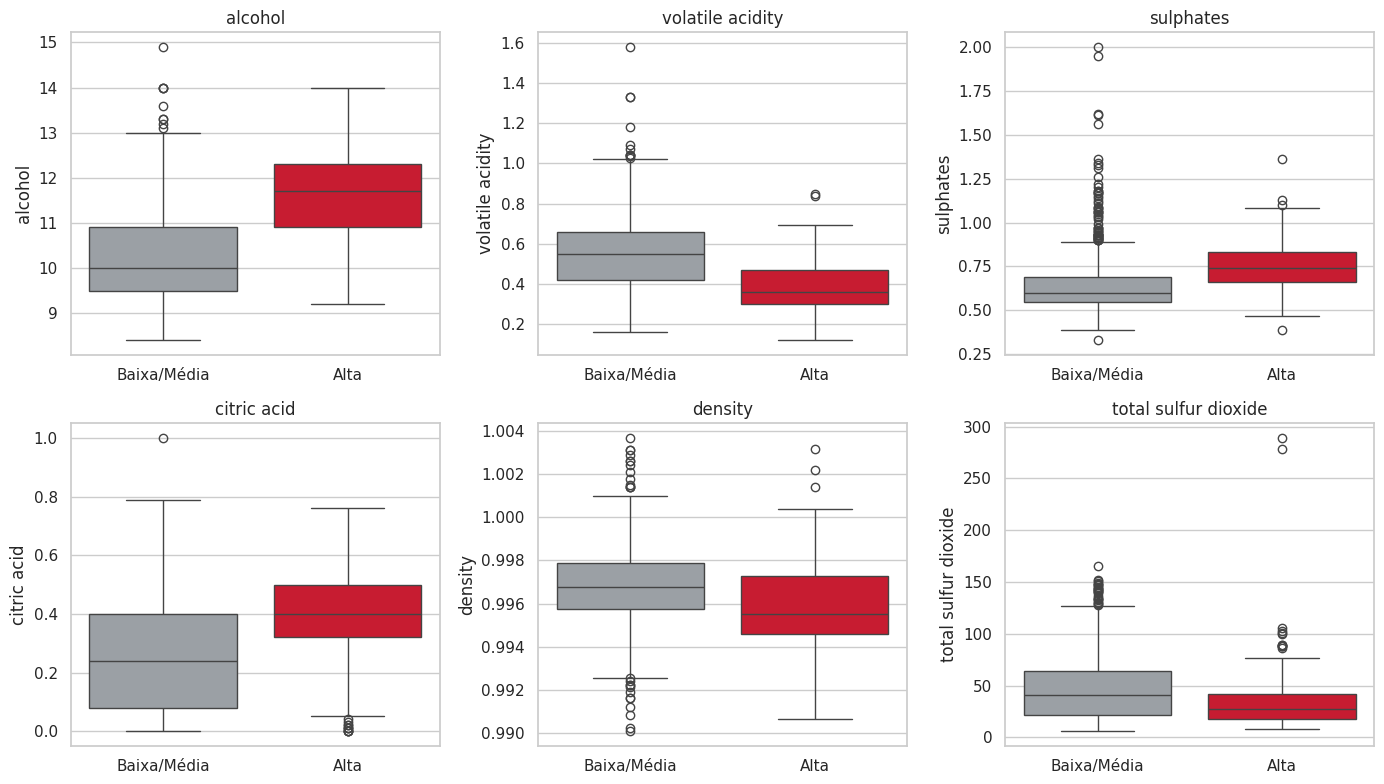

In [7]:
key = ['alcohol','volatile acidity','sulphates','citric acid','density','total sulfur dioxide']
fig, axes = plt.subplots(2,3, figsize=(14,8))
for ax,v in zip(axes.ravel(), key):
    sns.boxplot(data=df, x='high_quality', y=v, ax=ax, hue='high_quality',
                palette=['#9aa0a6', SPOT_RED], legend=False)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Baixa/Média','Alta']); ax.set_xlabel(''); ax.set_title(v)
plt.tight_layout(); plt.show()

### 2.5 Detecção de outliers (regra do IQR 1.5×)

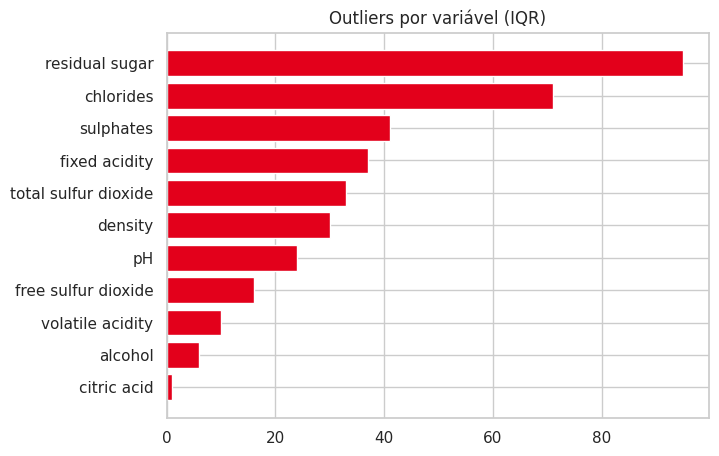

residual sugar          95
chlorides               71
sulphates               41
fixed acidity           37
total sulfur dioxide    33
density                 30
pH                      24
free sulfur dioxide     16
volatile acidity        10
alcohol                  6
citric acid              1
dtype: int64


In [8]:
out = {}
for c in FEATURES:
    q1,q3 = df[c].quantile([.25,.75]); iqr=q3-q1
    out[c] = int(((df[c]<q1-1.5*iqr)|(df[c]>q3+1.5*iqr)).sum())
oc = pd.Series(out).sort_values()
fig, ax = plt.subplots(figsize=(7,5))
ax.barh(oc.index, oc.values, color=SPOT_RED); ax.set_title('Outliers por variável (IQR)'); plt.show()
print(oc.sort_values(ascending=False))

Há outliers em quase todas as variáveis, principalmente em `residual sugar`,
`chlorides` e nos dióxidos de enxofre. **Decisão:** não removemos os outliers —
eles representam variação física real do produto e os modelos de árvore (Random Forest,
Gradient Boosting) são robustos a eles. Removê-los reduziria ainda mais a já escassa
classe positiva.

## 3. Pré-processamento e Feature Engineering

- **Nulos:** não há.
- **Padronização:** aplicada via `StandardScaler` **dentro do pipeline** (só para a Regressão Logística, que é sensível à escala). Fazê-lo dentro do pipeline evita vazamento de dados.
- **Novas features (com justificativa enológica):**

In [9]:
eps = 1e-6
df['free_sulfur_ratio'] = df['free sulfur dioxide']/(df['total sulfur dioxide']+eps)
df['total_acidity'] = df['fixed acidity']+df['volatile acidity']+df['citric acid']
df['alcohol_density_ratio'] = df['alcohol']/(df['density']+eps)
df['sulphates_chlorides_ratio'] = df['sulphates']/(df['chlorides']+eps)

feat_cols = [c for c in df.columns if c not in ('quality','high_quality')]
X = df[feat_cols]; y = df['high_quality']
print('Total de features:', X.shape[1])
print(feat_cols)

Total de features: 15
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'free_sulfur_ratio', 'total_acidity', 'alcohol_density_ratio', 'sulphates_chlorides_ratio']


**Justificativa das features criadas:**
- `free_sulfur_ratio`: fração do SO₂ que está livre (poder antioxidante efetivamente ativo).
- `total_acidity`: estrutura ácida total do vinho.
- `alcohol_density_ratio`: proxy de corpo/concentração.
- `sulphates_chlorides_ratio`: equilíbrio entre conservante e sais.

## 4. Desenvolvimento dos Modelos

Treinamos **três** classificadores e comparamos. Split estratificado (80/20) preserva a proporção de classes. `class_weight='balanced'` compensa o desbalanceamento.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

models = {
 'Regressão Logística': Pipeline([('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))]),
 'Random Forest': Pipeline([('clf', RandomForestClassifier(n_estimators=400,
    min_samples_leaf=2, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE))]),
 'Gradient Boosting': Pipeline([('clf', GradientBoostingClassifier(n_estimators=300,
    learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE))]),
}
print('Treino:', X_train.shape[0], '| Teste:', X_test.shape[0])

Treino: 814 | Teste: 204


## 5. Avaliação e Comparação

Para classes desbalanceadas, priorizamos **ROC-AUC** e **F1** sobre a acurácia. Usamos validação cruzada estratificada (5 folds) no treino para uma estimativa robusta.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results, fitted, roc_data = {}, {}, {}
for name, m in models.items():
    cv_auc = cross_val_score(m, X_train, y_train, cv=cv, scoring='roc_auc')
    m.fit(X_train, y_train); fitted[name]=m
    yp = m.predict(X_test); pr = m.predict_proba(X_test)[:,1]
    results[name] = {'accuracy':accuracy_score(y_test,yp),'precision':precision_score(y_test,yp,zero_division=0),
        'recall':recall_score(y_test,yp),'f1':f1_score(y_test,yp),'roc_auc':roc_auc_score(y_test,pr),
        'cv_auc':cv_auc.mean()}
    fpr,tpr,_ = roc_curve(y_test,pr); roc_data[name]=(fpr,tpr,results[name]['roc_auc'])

comp = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
comp.round(3)

,accuracy,precision,recall,f1,roc_auc,cv_auc
Random Forest,0.902,0.706,0.444,0.545,0.916,0.876
Gradient Boosting,0.882,0.571,0.444,0.500,0.886,0.868
Regressão Logística,0.789,0.357,0.741,0.482,0.884,0.883


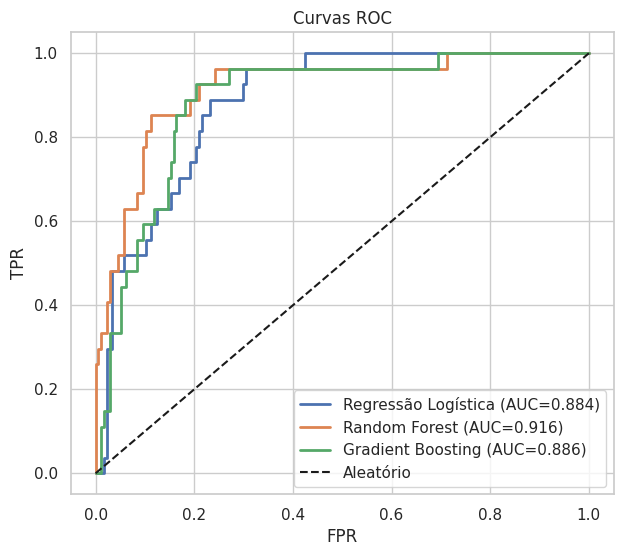

In [12]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(7,6))
for n,(fpr,tpr,auc) in roc_data.items(): ax.plot(fpr,tpr,lw=2,label=f'{n} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--',label='Aleatório')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Curvas ROC'); ax.legend(); plt.show()

Melhor modelo: Random Forest


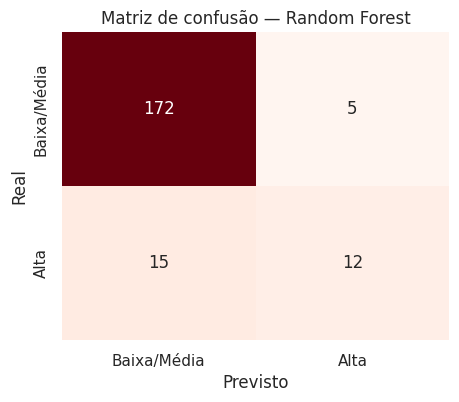

              precision    recall  f1-score   support

 Baixa/Média       0.92      0.97      0.95       177
        Alta       0.71      0.44      0.55        27

    accuracy                           0.90       204
   macro avg       0.81      0.71      0.75       204
weighted avg       0.89      0.90      0.89       204



In [13]:
best = comp.index[0]; bm = fitted[best]
print('Melhor modelo:', best)
cm = confusion_matrix(y_test, bm.predict(X_test))
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
    xticklabels=['Baixa/Média','Alta'], yticklabels=['Baixa/Média','Alta'])
ax.set_xlabel('Previsto'); ax.set_ylabel('Real'); ax.set_title(f'Matriz de confusão — {best}'); plt.show()
print(classification_report(y_test, bm.predict(X_test), target_names=['Baixa/Média','Alta']))

**Comparação dos modelos:**
- **Random Forest** alcança o maior ROC-AUC (~0,92) e a melhor precisão — quando ele
  diz que um vinho é de alta qualidade, costuma estar certo.
- **Regressão Logística** tem o maior **recall** (~0,74): captura mais vinhos bons,
  ao custo de mais falsos positivos. Útil se o objetivo for *não deixar passar* um vinho premium.
- A escolha final depende do objetivo de negócio (precisão vs. cobertura).

## 6. Interpretação dos Resultados

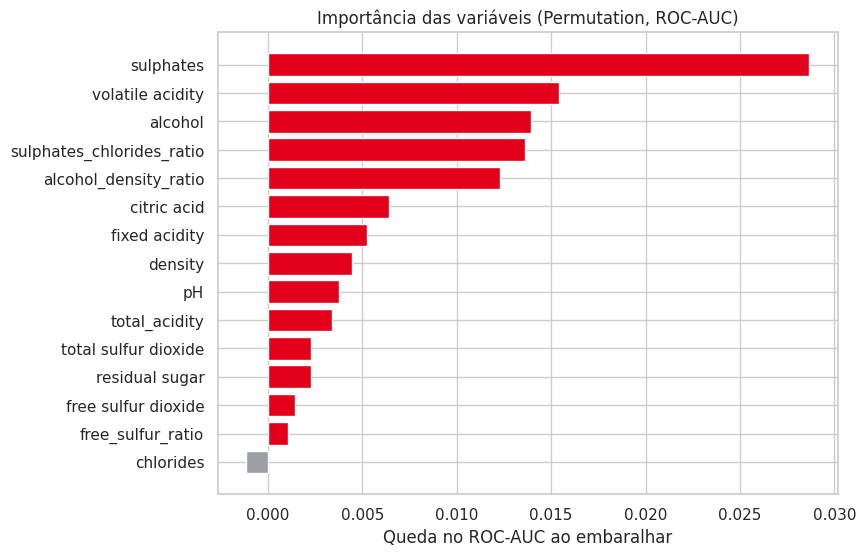

sulphates                    0.028674
volatile acidity             0.015436
alcohol                      0.013922
sulphates_chlorides_ratio    0.013622
alcohol_density_ratio        0.012283
citric acid                  0.006445
fixed acidity                0.005256
density                      0.004457
dtype: float64


In [14]:
perm = permutation_importance(bm, X_test, y_test, n_repeats=30,
    random_state=RANDOM_STATE, scoring='roc_auc')
imp = pd.Series(perm.importances_mean, index=feat_cols).sort_values()
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(imp.index, imp.values, color=[SPOT_RED if v>0 else '#9aa0a6' for v in imp.values])
ax.set_title('Importância das variáveis (Permutation, ROC-AUC)')
ax.set_xlabel('Queda no ROC-AUC ao embaralhar'); plt.show()
print(imp.sort_values(ascending=False).head(8))

### Conclusões e implicações para a produção

**Variáveis que mais influenciam a qualidade:**
1. **Sulfatos** — o controle de sulfatos (conservação/antioxidação) é o fator mais
   determinante para distinguir vinhos de alta qualidade.
2. **Acidez volátil** — manter baixa é crítico; o excesso (avinagrado) destrói a nota.
3. **Álcool** — maior teor alcoólico está associado a melhor avaliação.
4. As features de engenharia (`sulphates_chlorides_ratio`, `alcohol_density_ratio`)
   aparecem entre as mais importantes, validando a feature engineering.

**Recomendações práticas para o enólogo:**
- Monitorar e ajustar **sulfatos** dentro de uma faixa ótima durante a vinificação.
- Controlar rigorosamente a **acidez volátil** (higiene, controle de fermentação).
- Favorecer mostos que resultem em maior **teor alcoólico** quando o estilo permitir.

**Limitações:** classe positiva pequena (~14%) limita o recall; um dataset maior e
balanceado, ou técnicas como SMOTE e ajuste de threshold, poderiam melhorar a captura
de vinhos premium.